# Micrograd — Karpathy's Zero to Hero, Lecture 1

Building a tiny autograd engine from scratch.

In [16]:
import math
from graphviz import Digraph

## What is a Value?

A Value is NOT just a number.

It stores:
- data
- grad
- parents (`_prev`)
- operation that created it (`_op`)

Therefore every `Value` object is a node in the computation graph.

In [17]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda
        # if _backward is back prop and shouldnt it tech j be a function which calculates the local derivative when u give 1) the operator, 2) the derivative of the parent and 3) .data of both children?
        # why do we need to use lambda
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) -1 ) / (math.exp (2*x) +1)
        out = Value(t, (self, ), 'tanh')
        # u wrap self in a tuple cuz u defined _children=() as a tuple right but why do u right (self,) instead of (self) cuz technically the tuple only has 1 element.
        return out

## Graphviz helper

Traces the graph starting from a root `Value` and renders it left-to-right.

In [18]:
def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))

        dot.node(
            name=uid,
            label="{ %s | data %.4f | grad %.4f }" % (
                n.label, n.data, n.grad
            ),
            shape='record'
        )

        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

## Toy graph

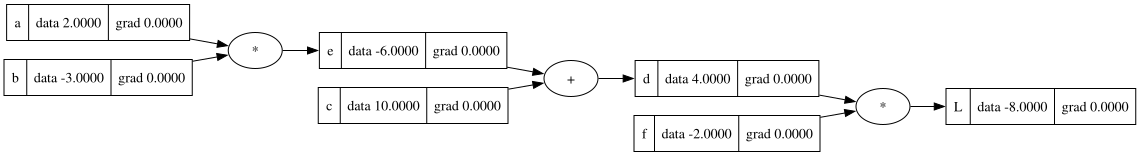

In [19]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')

e = a * b
e.label = 'e'

d = e + c
d.label = 'd'

f = Value(-2.0, label='f')

L = d * f
L.label = 'L'

draw_dot(L)

## Neuron example

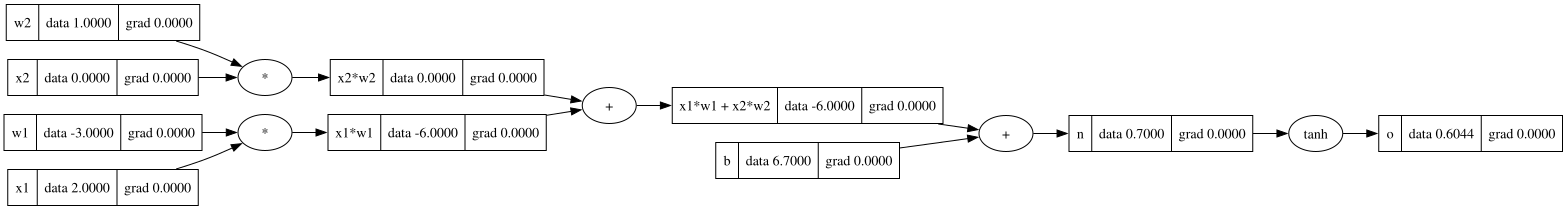

In [20]:
# inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias
b = Value(6.7, label='b')

# weighted inputs
x1w1 = x1 * w1
x1w1.label = 'x1*w1'

x2w2 = x2 * w2
x2w2.label = 'x2*w2'

# weighted sum
x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = 'x1*w1 + x2*w2'

# add bias
n = x1w1x2w2 + b
n.label = 'n'
o = n.tanh()
o.label = 'o'
draw_dot(o)

`tanh()` is implemented and `o = n.tanh()` renders correctly.

**Next up:**
- understand local derivatives
- implement `_backward()`
- topological sort
- `backward()`

## Local derivative

Each operation only knows how to differentiate itself.

Addition:
dz/dx = 1

Multiplication:
dz/dx = y

Tanh:
dz/dx = 1 - tanh²(x)

Backprop stitches these local derivatives together using the chain rule.